In [1]:
from ultralytics import YOLO
import os
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import cv2
import random

In [2]:
# ---------- bbox helpers ----------

def calculate_iou(box1, box2):
    """box format: [x1, y1, x2, y2]"""
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])
    inter = max(0, x2 - x1) * max(0, y2 - y1)
    a1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
    a2 = (box2[2] - box2[0]) * (box2[3] - box2[1])
    union = a1 + a2 - inter
    return inter / union if union > 0 else 0.0


def yolo_to_xyxy(yolo_box, img_width, img_height):
    """YOLO 歸一化 [cx, cy, w, h] -> [x1, y1, x2, y2]"""
    cx, cy, w, h = yolo_box
    return [
        (cx - w / 2) * img_width,
        (cy - h / 2) * img_height,
        (cx + w / 2) * img_width,
        (cy + h / 2) * img_height,
    ]


def box_center(box):
    return np.array([(box[0] + box[2]) / 2, (box[1] + box[3]) / 2])


def greedy_nms(boxes, scores, iou_threshold):
    """Greedy NMS. Returns indices of kept boxes."""
    if not boxes:
        return []
    boxes  = np.array(boxes)
    scores = np.array(scores)
    order  = scores.argsort()[::-1]
    kept, suppressed = [], set()
    for i in [int(x) for x in order]:
        if i in suppressed:
            continue
        kept.append(i)
        for j in [int(x) for x in order]:
            if j == i or j in suppressed:
                continue
            if calculate_iou(boxes[i], boxes[j]) >= iou_threshold:
                suppressed.add(j)
    return kept


# ---------- GT loading ----------

def load_gt_boxes(od_image_path, img_width, img_height):
    """Load GT bounding boxes from OD-format label file."""
    label_path = (
        od_image_path
        .replace('/images/', '/labels/')
        .replace('.png', '.txt')
        .replace('.jpg', '.txt')
    )
    gt_nodule, gt_maybe = [], []
    if Path(label_path).exists():
        with open(label_path) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) < 5:
                    continue
                class_id = int(float(parts[0]))
                xyxy = yolo_to_xyxy(list(map(float, parts[1:5])), img_width, img_height)
                if class_id == 0:
                    gt_nodule.append(xyxy)
                elif class_id == 1:
                    gt_maybe.append(xyxy)
    return gt_nodule, gt_maybe


# ---------- extract predictions ----------

def extract_nodule_preds(result):
    """Extract class-0 predictions as list of {'box', 'conf'}."""
    preds = []
    if result.boxes is not None and len(result.boxes) > 0:
        cls_arr  = result.boxes.cls.cpu().numpy()
        xyxy_arr = result.boxes.xyxy.cpu().numpy()
        conf_arr = result.boxes.conf.cpu().numpy()
        for i, cls in enumerate(cls_arr):
            if int(cls) == 0:
                preds.append({'box': xyxy_arr[i].tolist(), 'conf': float(conf_arr[i])})
    return preds

In [3]:
def fuse_predictions(od_result, seg_result, strategy='or', nms_iou=0.5):
    """
    Fuse predictions from OD and Seg models.

    strategy:
      'or'  - 聯集: 兩個模型的預測框全部合併，再做 greedy NMS
      'and' - 交集: 只保留兩個模型都同意的框（IoU >= nms_iou），
               框取平均座標，conf 取平均

    Returns list of {'box': [x1,y1,x2,y2], 'conf': float, 'source': str}
    """
    od_preds  = extract_nodule_preds(od_result)
    seg_preds = extract_nodule_preds(seg_result)

    if strategy == 'or':
        all_boxes = [p['box']  for p in od_preds + seg_preds]
        all_confs = [p['conf'] for p in od_preds + seg_preds]
        all_srcs  = ['od'] * len(od_preds) + ['seg'] * len(seg_preds)
        if not all_boxes:
            return []
        kept = greedy_nms(all_boxes, all_confs, nms_iou)
        return [{'box': all_boxes[k], 'conf': all_confs[k], 'source': all_srcs[k]}
                for k in kept]

    elif strategy == 'and':
        fused = []
        matched_seg = set()
        for i, op in enumerate(od_preds):
            best_iou, best_j = 0, -1
            for j, sp in enumerate(seg_preds):
                if j in matched_seg:
                    continue
                iou = calculate_iou(op['box'], sp['box'])
                if iou > best_iou:
                    best_iou, best_j = iou, j
            if best_iou >= nms_iou:
                matched_seg.add(best_j)
                sp = seg_preds[best_j]
                avg_conf   = (op['conf'] + sp['conf']) / 2
                merged_box = [(op['box'][k] + sp['box'][k]) / 2 for k in range(4)]
                fused.append({'box': merged_box, 'conf': avg_conf, 'source': 'both'})
        return fused

    else:
        raise ValueError(f"Unknown strategy: '{strategy}'. Use 'or' or 'and'.")

In [4]:
def match_and_build_records(pred_entries, gt_nodule, gt_maybe,
                             patient_id, file_name, iou_threshold):
    """
    pred_entries : list of {'box': [x1,y1,x2,y2], 'conf': float}
    Returns list of record dicts (TP / FP / FN / TN).
    """
    matched_gt   = set()
    matched_pred = set()
    ignored_pred = set()
    matched_pairs = []

    for i, pred in enumerate(pred_entries):
        best_iou, best_j = 0, -1
        for j, gt_box in enumerate(gt_nodule):
            if j in matched_gt:
                continue
            iou = calculate_iou(pred['box'], gt_box)
            if iou > best_iou:
                best_iou, best_j = iou, j

        if best_iou >= iou_threshold:
            matched_gt.add(best_j)
            matched_pred.add(i)
            matched_pairs.append((i, best_j, best_iou))
        else:
            maybe_iou = max(
                (calculate_iou(pred['box'], gb) for gb in gt_maybe), default=0
            )
            if maybe_iou >= iou_threshold:
                ignored_pred.add(i)

    records = []
    base = {'patient_ID': patient_id, 'file_name': file_name}

    for pred_i, gt_j, iou in matched_pairs:
        pb, gb = pred_entries[pred_i]['box'], gt_nodule[gt_j]
        records.append({**base,
            'match_type': 'TP', 'pred_box': pb, 'gt_box': gb,
            'iou': iou,
            'conf': pred_entries[pred_i]['conf'],
            'center_distance': float(np.linalg.norm(box_center(pb) - box_center(gb))),
            'source': pred_entries[pred_i].get('source', ''),
        })

    for i, pred in enumerate(pred_entries):
        if i not in matched_pred and i not in ignored_pred:
            records.append({**base,
                'match_type': 'FP', 'pred_box': pred['box'], 'gt_box': None,
                'iou': 0.0, 'conf': pred['conf'], 'center_distance': None,
                'source': pred.get('source', ''),
            })

    for j, gb in enumerate(gt_nodule):
        if j not in matched_gt:
            records.append({**base,
                'match_type': 'FN', 'pred_box': None, 'gt_box': gb,
                'iou': 0.0, 'conf': None, 'center_distance': None, 'source': None,
            })

    if not records:
        records.append({**base,
            'match_type': 'TN',
            'pred_box': None, 'gt_box': None,
            'iou': None, 'conf': None, 'center_distance': None, 'source': None,
        })
    return records


def get_records(od_result, seg_result, od_image_path,
                strategy, patient_id, iou_threshold, nms_iou):
    """
    strategy: 'od_only' | 'seg_only' | 'or' | 'and'
    GT is always loaded from OD-format label (bbox).
    """
    img_height, img_width = od_result.orig_shape
    gt_nodule, gt_maybe  = load_gt_boxes(od_image_path, img_width, img_height)
    file_name = Path(od_image_path).name

    if strategy == 'od_only':
        preds = extract_nodule_preds(od_result)
    elif strategy == 'seg_only':
        preds = extract_nodule_preds(seg_result)
    else:  # 'or' / 'and'
        preds = fuse_predictions(od_result, seg_result,
                                  strategy=strategy, nms_iou=nms_iou)

    return match_and_build_records(preds, gt_nodule, gt_maybe,
                                    patient_id, file_name, iou_threshold)

In [5]:
def compute_metrics_from_counts(tp, fp, fn):
    eta = 1e-9
    recall    = tp / (tp + fn + eta)
    precision = tp / (tp + fp + eta)
    f1        = 2 * precision * recall / (precision + recall + eta)
    return recall, precision, f1


def get_image_metrics(df):
    counts = (
        df[df['match_type'].isin(['TP', 'FP', 'FN'])]
        .groupby(['file_name', 'match_type']).size().unstack(fill_value=0)
    )
    for col in ['TP', 'FP', 'FN']:
        if col not in counts:
            counts[col] = 0
    counts[['recall', 'precision', 'f1']] = [
        compute_metrics_from_counts(r.TP, r.FP, r.FN) for _, r in counts.iterrows()
    ]
    return counts


def get_patient_metrics(df):
    counts = (
        df[df['match_type'].isin(['TP', 'FP', 'FN'])]
        .groupby(['patient_ID', 'match_type']).size().unstack(fill_value=0)
    )
    for col in ['TP', 'FP', 'FN']:
        if col not in counts:
            counts[col] = 0
    counts[['recall', 'precision', 'f1']] = [
        compute_metrics_from_counts(r.TP, r.FP, r.FN) for _, r in counts.iterrows()
    ]
    return counts


def summarize(df, label=''):
    img_df = get_image_metrics(df)
    pat_df = get_patient_metrics(df)
    tag = f"[{label}] " if label else "  "
    print(f"{tag}Image-wise   | recall={img_df['recall'].mean():.4f}  "
          f"precision={img_df['precision'].mean():.4f}  F1={img_df['f1'].mean():.4f}")
    print(f"{tag}Patient-wise | recall={pat_df['recall'].mean():.4f}  "
          f"precision={pat_df['precision'].mean():.4f}  F1={pat_df['f1'].mean():.4f}")
    tp_iou = df.loc[df['match_type'] == 'TP', 'iou'].dropna()
    if len(tp_iou):
        print(f"{tag}TP IoU       | n={len(tp_iou)}  mean={tp_iou.mean():.4f}  "
              f"median={tp_iou.median():.4f}  std={tp_iou.std():.4f}")
    tp_cd = df.loc[df['match_type'] == 'TP', 'center_distance'].dropna()
    if len(tp_cd):
        print(f"{tag}Center dist  | n={len(tp_cd)}  mean={tp_cd.mean():.2f}  "
              f"median={tp_cd.median():.2f}  max={tp_cd.max():.2f}")
    return img_df, pat_df


def calculate_ap(df):
    """101-point interpolated AP (COCO style)."""
    total_gt = df['match_type'].isin(['TP', 'FN']).sum()
    if total_gt == 0:
        return 0.0, np.array([]), np.array([])
    preds = (
        df[df['match_type'].isin(['TP', 'FP'])].dropna(subset=['conf'])
        .sort_values('conf', ascending=False).reset_index(drop=True)
    )
    if len(preds) == 0:
        return 0.0, np.array([0.0]), np.array([0.0])
    tp_cs = (preds['match_type'] == 'TP').cumsum().values
    fp_cs = (preds['match_type'] == 'FP').cumsum().values
    recalls    = tp_cs / total_gt
    precisions = tp_cs / (tp_cs + fp_cs)
    ap = 0.0
    for thr in np.linspace(0, 1, 101):
        p = precisions[recalls >= thr]
        ap += p.max() if len(p) > 0 else 0.0
    return ap / 101, recalls, precisions

In [8]:
data_root = "/datadrive"

In [11]:
od_name  = "2026_03_11(1)"
seg_name = "2026_03_12(1)"

od_model  = YOLO(f'{data_root}/yolo_output/runs/detect/{od_name}/weights/best.pt')
seg_model = YOLO(f'{data_root}/yolo_output/runs/seg/{seg_name}/weights/best.pt')

print(f"OD  model: {od_name}")
print(f"Seg model: {seg_name}")

OD  model: 2026_03_11(1)
Seg model: 2026_03_12(1)


In [14]:
data_df = pd.read_csv(f'{data_root}/yolo_data/all_csv_files/combined_dataset_info_v5.csv')

val_df = data_df[
    (data_df['dataset'] == 'CG') &
    (data_df['train_or_test'] == 'test') &
    (data_df['nodule_type'] != 'none')
]

od_root  = f'{data_root}/yolo_data/all_data_nodule_normal_cut_od/images'
seg_root = f'{data_root}/yolo_data/all_data_nodule_normal_cut_seg/images'

od_file_list  = [os.path.join(od_root,  f"{fn}.png") for fn in val_df['file_name']]
seg_file_list = [os.path.join(seg_root, f"{fn}.png") for fn in val_df['file_name']]
pid_list      = val_df['patient_ID'].tolist()

print(f"Total images: {len(od_file_list)}")

Total images: 1444


In [15]:
import torch

device         = 0
conf_threshold = 0.5
batch_size     = 32

print(f"Using device: {device}")

# --- OD inference ---
od_raw = []   # (od_image_path, pid, od_result)
for i in tqdm(range(0, len(od_file_list), batch_size), desc="OD  Inference"):
    batch_paths = od_file_list[i:i + batch_size]
    batch_pids  = pid_list[i:i + batch_size]
    for path, pid, res in zip(
        batch_paths, batch_pids,
        od_model(batch_paths, conf=conf_threshold, verbose=False, device=device)
    ):
        od_raw.append((path, pid, res))

# --- Seg inference ---
seg_raw = []  # (seg_image_path, pid, seg_result)
for i in tqdm(range(0, len(seg_file_list), batch_size), desc="Seg Inference"):
    batch_paths = seg_file_list[i:i + batch_size]
    batch_pids  = pid_list[i:i + batch_size]
    for path, pid, res in zip(
        batch_paths, batch_pids,
        seg_model(batch_paths, conf=conf_threshold, verbose=False, device=device)
    ):
        seg_raw.append((path, pid, res))

print(f"OD  inference done: {len(od_raw)} images")
print(f"Seg inference done: {len(seg_raw)} images")

Using device: 0


Seg Inference: 100%|██████████| 46/46 [00:24<00:00,  1.91it/s]

OD  inference done: 1444 images
Seg inference done: 1444 images


In [16]:
# --- 評估設定 ---
strategies            = ['od_only', 'seg_only', 'or', 'and']
nms_iou               = 0.5   # 融合時 NMS / AND 判斷用的 IoU 門檻
iou_thresholds_report = [0.3, 0.5, 0.7]
iou_thresholds_map    = list(np.round(np.arange(0.5, 1.0, 0.05), 2))
all_iou_thresholds    = sorted(set(iou_thresholds_report + iou_thresholds_map))

# results_by_strategy_iou[strategy][iou_threshold] = DataFrame
results_by_strategy_iou = {s: {} for s in strategies}

for iou_threshold in tqdm(all_iou_thresholds, desc="Matching"):
    for strategy in strategies:
        all_records = []
        for (od_path, pid, od_res), (_, _, seg_res) in zip(od_raw, seg_raw):
            records = get_records(
                od_res, seg_res, od_path,
                strategy=strategy,
                patient_id=pid,
                iou_threshold=iou_threshold,
                nms_iou=nms_iou,
            )
            all_records.extend(records)
        results_by_strategy_iou[strategy][iou_threshold] = pd.DataFrame(all_records)

# --- 印出 report thresholds ---
strategy_labels = {
    'od_only':  'OD only',
    'seg_only': 'Seg only (bbox)',
    'or':       'Fusion OR (union)',
    'and':      'Fusion AND (intersection)',
}

for iou_threshold in iou_thresholds_report:
    print(f"\n{'='*60}")
    print(f"IoU threshold = {iou_threshold}")
    print('='*60)
    for strategy in strategies:
        print(f"  --- {strategy_labels[strategy]} ---")
        summarize(results_by_strategy_iou[strategy][iou_threshold])

Matching: 100%|██████████| 11/11 [00:40<00:00,  3.72s/it]



IoU threshold = 0.3
  --- OD only ---
  Image-wise   | recall=0.9210  precision=0.9439  F1=0.9267
  Patient-wise | recall=0.9149  precision=0.9695  F1=0.9354
  TP IoU       | n=1402  mean=0.8614  median=0.8830  std=0.0927
  Center dist  | n=1402  mean=3.72  median=2.34  max=91.38
  --- Seg only (bbox) ---
  Image-wise   | recall=0.9178  precision=0.9442  F1=0.9247
  Patient-wise | recall=0.9092  precision=0.9660  F1=0.9302
  TP IoU       | n=1394  mean=0.8593  median=0.8810  std=0.0911
  Center dist  | n=1394  mean=3.86  median=2.33  max=92.99
  --- Fusion OR (union) ---
  Image-wise   | recall=0.9440  precision=0.9635  F1=0.9480
  Patient-wise | recall=0.9384  precision=0.9739  F1=0.9514
  TP IoU       | n=1441  mean=0.8590  median=0.8821  std=0.0936
  Center dist  | n=1441  mean=3.81  median=2.34  max=91.38
  --- Fusion AND (intersection) ---
  Image-wise   | recall=0.8937  precision=0.9258  F1=0.9041
  Patient-wise | recall=0.8850  precision=0.9677  F1=0.9159
  TP IoU       | n=135

In [19]:
results_by_strategy_iou

{'od_only': {0.3:                                     patient_ID  \
  0     5361EE8C3C1F32805CF7DCD382C3BBF132CEBF26   
  1     5361EE8C3C1F32805CF7DCD382C3BBF132CEBF26   
  2     63597A7850B0966D88F466C755AB523C988F09B7   
  3     63597A7850B0966D88F466C755AB523C988F09B7   
  4     CD713E603F7655DDC1803C1A9DD7CB7E2728E765   
  ...                                        ...   
  1592  F1AF2361D62D5577DF9B07D2FC149E9BA9A4D906   
  1593  F1AF2361D62D5577DF9B07D2FC149E9BA9A4D906   
  1594  E8DBD7B927570040D2C7CFF43084F559B5C2B7EC   
  1595  E8DBD7B927570040D2C7CFF43084F559B5C2B7EC   
  1596  E8DBD7B927570040D2C7CFF43084F559B5C2B7EC   
  
                                         file_name match_type  \
  0      d391e75a9b981397e84339c885c864da_left.png         TP   
  1     d391e75a9b981397e84339c885c864da_right.png         TP   
  2      c987dafe0bbd44b4ee4de353d7ddeb32_left.png         TP   
  3     c987dafe0bbd44b4ee4de353d7ddeb32_right.png         FN   
  4      93effacee0f8749285b35ba

In [17]:
rows = []

for strategy in strategies:
    # mAP@[0.5:0.95]
    aps_map = [calculate_ap(results_by_strategy_iou[strategy][iou])[0]
               for iou in iou_thresholds_map]
    mAP = float(np.mean(aps_map))

    for iou_threshold in iou_thresholds_report:
        ndf = results_by_strategy_iou[strategy][iou_threshold]

        ap, _, _ = calculate_ap(ndf)

        img_df = get_image_metrics(ndf)
        pat_df = get_patient_metrics(ndf)

        tp_iou = ndf.loc[ndf['match_type'] == 'TP', 'iou'].dropna()
        tp_cd  = ndf.loc[ndf['match_type'] == 'TP', 'center_distance'].dropna()

        rows.append({
            'strategy':          strategy_labels[strategy],
            'iou_threshold':     iou_threshold,
            'AP':                round(ap, 4),
            'mAP@0.5:0.95':     round(mAP, 4),
            'img_recall':        round(img_df['recall'].mean(),    4),
            'img_precision':     round(img_df['precision'].mean(), 4),
            'img_f1':            round(img_df['f1'].mean(),        4),
            'pat_recall':        round(pat_df['recall'].mean(),    4),
            'pat_precision':     round(pat_df['precision'].mean(), 4),
            'pat_f1':            round(pat_df['f1'].mean(),        4),
            'iou_mean':          round(tp_iou.mean(),   4) if len(tp_iou) > 0 else None,
            'iou_median':        round(tp_iou.median(), 4) if len(tp_iou) > 0 else None,
            'cd_mean':           round(tp_cd.mean(),    2) if len(tp_cd)  > 0 else None,
            'cd_median':         round(tp_cd.median(),  2) if len(tp_cd)  > 0 else None,
            'cd_max':            round(tp_cd.max(),     2) if len(tp_cd)  > 0 else None,
        })

summary_df = pd.DataFrame(rows).set_index(['strategy', 'iou_threshold'])
display(summary_df)

AP  mAP@0.5:0.95  img_recall  \
strategy                  iou_threshold                                     
OD only                   0.3            0.8898        0.6512      0.9210   
                          0.5            0.8669        0.6512      0.9099   
                          0.7            0.8299        0.6512      0.8761   
Seg only (bbox)           0.3            0.8783        0.6439      0.9178   
                          0.5            0.8653        0.6439      0.9094   
                          0.7            0.8253        0.6439      0.8748   
Fusion OR (union)         0.3            0.9085        0.6668      0.9440   
                          0.5            0.8952        0.6668      0.9339   
                          0.7            0.8479        0.6668      0.8956   
Fusion AND (intersection) 0.3            0.8606        0.6413      0.8937   
                          0.5            0.8474        0.6413      0.8844   
                          0.7            0.8108        0.6413      0.8585   

                                         img_precision  img_f1  pat_recall  \
strategy                  iou_threshold                                      
OD only                   0.3                   0.9439  0.9267      0.9149   
                          0.5                   0.9317  0.9153      0.9074   
                          0.7                   0.8960  0.8811      0.8758   
Seg only (bbox)           0.3                   0.9442  0.9247      0.9092   
                          0.5                   0.9356  0.9164      0.9039   
                          0.7                   0.8995  0.8812      0.8721   
Fusion OR (union)         0.3                   0.9635  0.9480      0.9384   
                          0.5                   0.9528  0.9377      0.9312   
                          0.7                   0.9133  0.8992      0.8973   
Fusion AND (intersection) 0.3                   0.9258  0.9041      0.8850   
                          0.5                   0.9161  0.8946      0.8797   
                          0.7                   0.8874  0.8677      0.8565   

                                         pat_precision  pat_f1  iou_mean  \
strategy                  iou_threshold                                    
OD only                   0.3                   0.9695  0.9354    0.8614   
                          0.5                   0.9603  0.9274    0.8675   
                          0.7                   0.9251  0.8943    0.8770   
Seg only (bbox)           0.3                   0.9660  0.9302    0.8593   
                          0.5                   0.9586  0.9241    0.8647   
                          0.7                   0.9227  0.8906    0.8737   
Fusion OR (union)         0.3                   0.9739  0.9514    0.8590   
                          0.5                   0.9654  0.9438    0.8651   
                          0.7                   0.9267  0.9080    0.8752   
Fusion AND (intersection) 0.3                   0.9677  0.9159    0.8670   
                          0.5                   0.9590  0.9097    0.8719   
                          0.7                   0.9308  0.8846    0.8792   

                                         iou_median  cd_mean  cd_median  \
strategy                  iou_threshold                                   
OD only                   0.3                0.8830     3.72       2.34   
                          0.5                0.8839     3.30       2.32   
                          0.7                0.8877     3.00       2.28   
Seg only (bbox)           0.3                0.8810     3.86       2.33   
                          0.5                0.8819     3.40       2.32   
                          0.7                0.8855     3.10       2.28   
Fusion OR (union)         0.3                0.8821     3.81       2.34   
                          0.5                0.8838     3.40       2.33   
                          0.7                0.8871     3.

In [18]:
out_dir = f'{data_root}/yolo_output/ensemble_{od_name}__{seg_name}'
os.makedirs(out_dir, exist_ok=True)
summary_df.to_csv(os.path.join(out_dir, 'ensemble_metrics.csv'))
print(f"Saved to {out_dir}/ensemble_metrics.csv")

Saved to /datadrive/yolo_output/ensemble_2026_03_11(1)__2026_03_12(1)/ensemble_metrics.csv


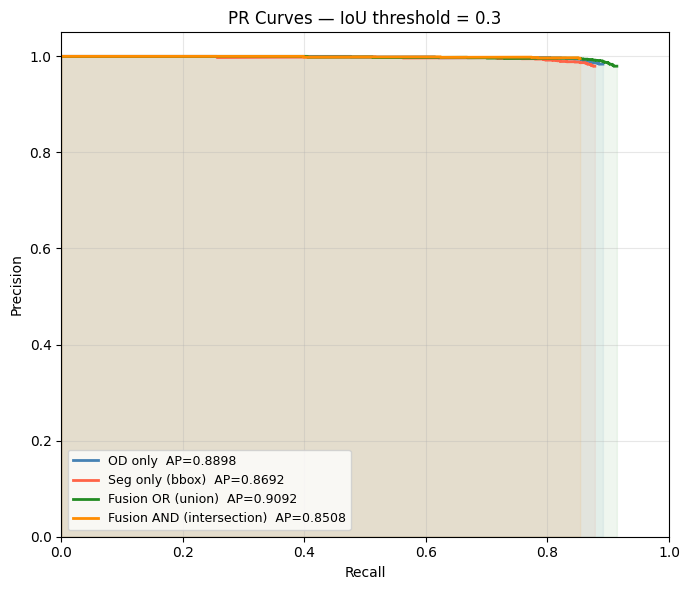

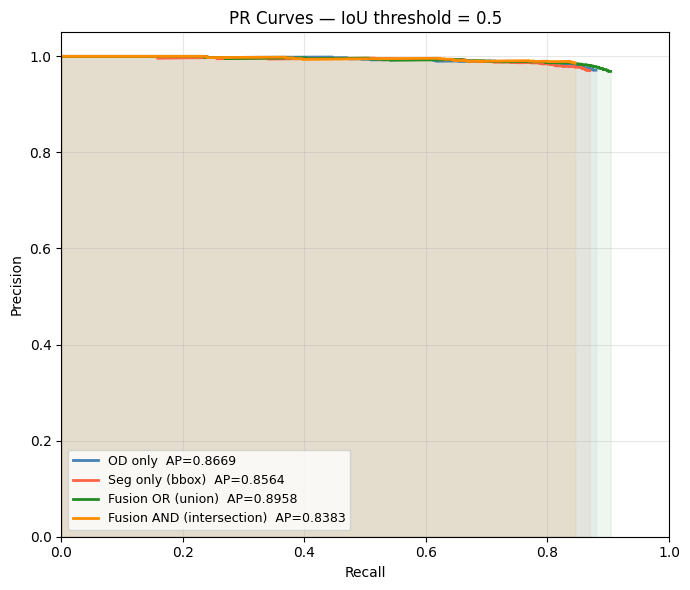

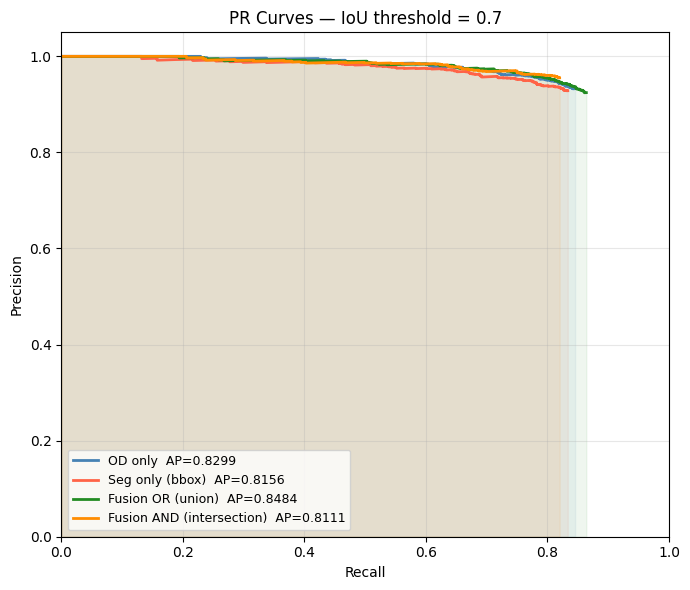

In [12]:
colors = {'od_only': 'steelblue', 'seg_only': 'tomato',
          'or': 'forestgreen', 'and': 'darkorange'}

for iou_threshold in iou_thresholds_report:
    fig, ax = plt.subplots(figsize=(7, 6))
    for strategy in strategies:
        ndf = results_by_strategy_iou[strategy][iou_threshold]
        ap, recalls, precisions = calculate_ap(ndf)
        if len(recalls) == 0:
            continue
        label = f"{strategy_labels[strategy]}  AP={ap:.4f}"
        ax.plot(recalls, precisions, color=colors[strategy], linewidth=2, label=label)
        ax.fill_between(recalls, precisions, alpha=0.07, color=colors[strategy])

    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')
    ax.set_title(f'PR Curves — IoU threshold = {iou_threshold}')
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1.05])
    ax.legend(fontsize=9, loc='lower left')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [13]:
def visualize_ensemble_samples(od_raw, seg_raw, results_by_strategy_iou,
                                od_root, strategy='or', iou_threshold=0.5,
                                n=16, mode='random', seed=42):
    """
    每張圖並排顯示 OD-only / Seg-only / Fused 結果。
    mode: 'random' | 'fp' | 'fn' | 'worst'
    """
    ndf_fused = results_by_strategy_iou[strategy][iou_threshold]
    grouped   = ndf_fused.groupby('file_name')

    if mode == 'random':
        rng = random.Random(seed)
        file_names = rng.sample(list(grouped.groups.keys()), min(n, len(grouped)))
    else:
        counts = (
            ndf_fused[ndf_fused['match_type'].isin(['FP', 'FN'])]
            .groupby(['file_name', 'match_type']).size().unstack(fill_value=0)
        )
        for col in ['FP', 'FN']:
            if col not in counts:
                counts[col] = 0
        if mode == 'fp':
            file_names = counts['FP'].nlargest(n).index.tolist()
        elif mode == 'fn':
            file_names = counts['FN'].nlargest(n).index.tolist()
        else:
            file_names = (counts['FP'] + counts['FN']).nlargest(n).index.tolist()

    # Build filename -> index map
    fname_to_idx = {Path(p).name: i for i, (p, _, _) in enumerate(od_raw)}

    color_map = {'TP_pred': 'lime', 'TP_gt': 'green',
                 'FP_pred': 'red',  'FN_gt': 'orange'}

    def draw_recs(ax, records):
        for rec in records:
            mt = rec['match_type']
            if mt == 'TP':
                for box, c, ls in [(rec['pred_box'], 'lime', '-'),
                                   (rec['gt_box'],   'green', '--')]:
                    if box:
                        ax.add_patch(mpatches.FancyBboxPatch(
                            (0, 0), 1, 1, visible=False))
                        ax.add_patch(plt.Rectangle(
                            (box[0], box[1]), box[2]-box[0], box[3]-box[1],
                            linewidth=2, edgecolor=c, facecolor='none', linestyle=ls))
                if rec['pred_box']:
                    ax.text(rec['pred_box'][0], rec['pred_box'][1]-4,
                            f"TP iou={rec['iou']:.2f}", color='lime', fontsize=6)
            elif mt == 'FP':
                b = rec['pred_box']
                if b:
                    ax.add_patch(plt.Rectangle(
                        (b[0], b[1]), b[2]-b[0], b[3]-b[1],
                        linewidth=2, edgecolor='red', facecolor='none'))
                    ax.text(b[0], b[1]-4, 'FP', color='red', fontsize=6)
            elif mt == 'FN':
                b = rec['gt_box']
                if b:
                    ax.add_patch(plt.Rectangle(
                        (b[0], b[1]), b[2]-b[0], b[3]-b[1],
                        linewidth=2, edgecolor='orange', facecolor='none', linestyle='--'))
                    ax.text(b[0], b[1]-4, 'FN', color='orange', fontsize=6)

    strategy_cols = ['od_only', 'seg_only', strategy]
    col_titles    = ['OD only', 'Seg only', f'Fusion ({strategy})']
    ncols, nrows  = len(strategy_cols), len(file_names)

    fig, axes = plt.subplots(nrows, ncols, figsize=(6*ncols, 5*nrows))
    if nrows == 1:
        axes = axes[np.newaxis, :]

    for row_i, fname in enumerate(file_names):
        idx = fname_to_idx.get(fname)
        if idx is None:
            continue
        od_path = od_raw[idx][0]
        img = cv2.cvtColor(cv2.imread(od_path), cv2.COLOR_BGR2RGB)

        for col_i, strat in enumerate(strategy_cols):
            ax = axes[row_i, col_i]
            ax.imshow(img)
            recs_df = results_by_strategy_iou[strat][iou_threshold]
            if fname in recs_df['file_name'].values:
                draw_recs(ax, recs_df[recs_df['file_name'] == fname].to_dict('records'))
            tp = (recs_df[recs_df['file_name'] == fname]['match_type'] == 'TP').sum()
            fp = (recs_df[recs_df['file_name'] == fname]['match_type'] == 'FP').sum()
            fn = (recs_df[recs_df['file_name'] == fname]['match_type'] == 'FN').sum()
            ax.set_title(f"{col_titles[col_i]}\n{fname}\nTP={tp} FP={fp} FN={fn}",
                         fontsize=8)
            ax.axis('off')

    legend_elems = [
        mpatches.Patch(edgecolor='lime',   facecolor='none', linestyle='-',  label='TP pred'),
        mpatches.Patch(edgecolor='green',  facecolor='none', linestyle='--', label='TP gt'),
        mpatches.Patch(edgecolor='red',    facecolor='none', linestyle='-',  label='FP'),
        mpatches.Patch(edgecolor='orange', facecolor='none', linestyle='--', label='FN'),
    ]
    fig.legend(handles=legend_elems, loc='lower center', ncol=4, fontsize=10)
    plt.suptitle(f"Ensemble comparison  |  IoU={iou_threshold}  |  mode={mode}", fontsize=13)
    plt.tight_layout()
    plt.show()

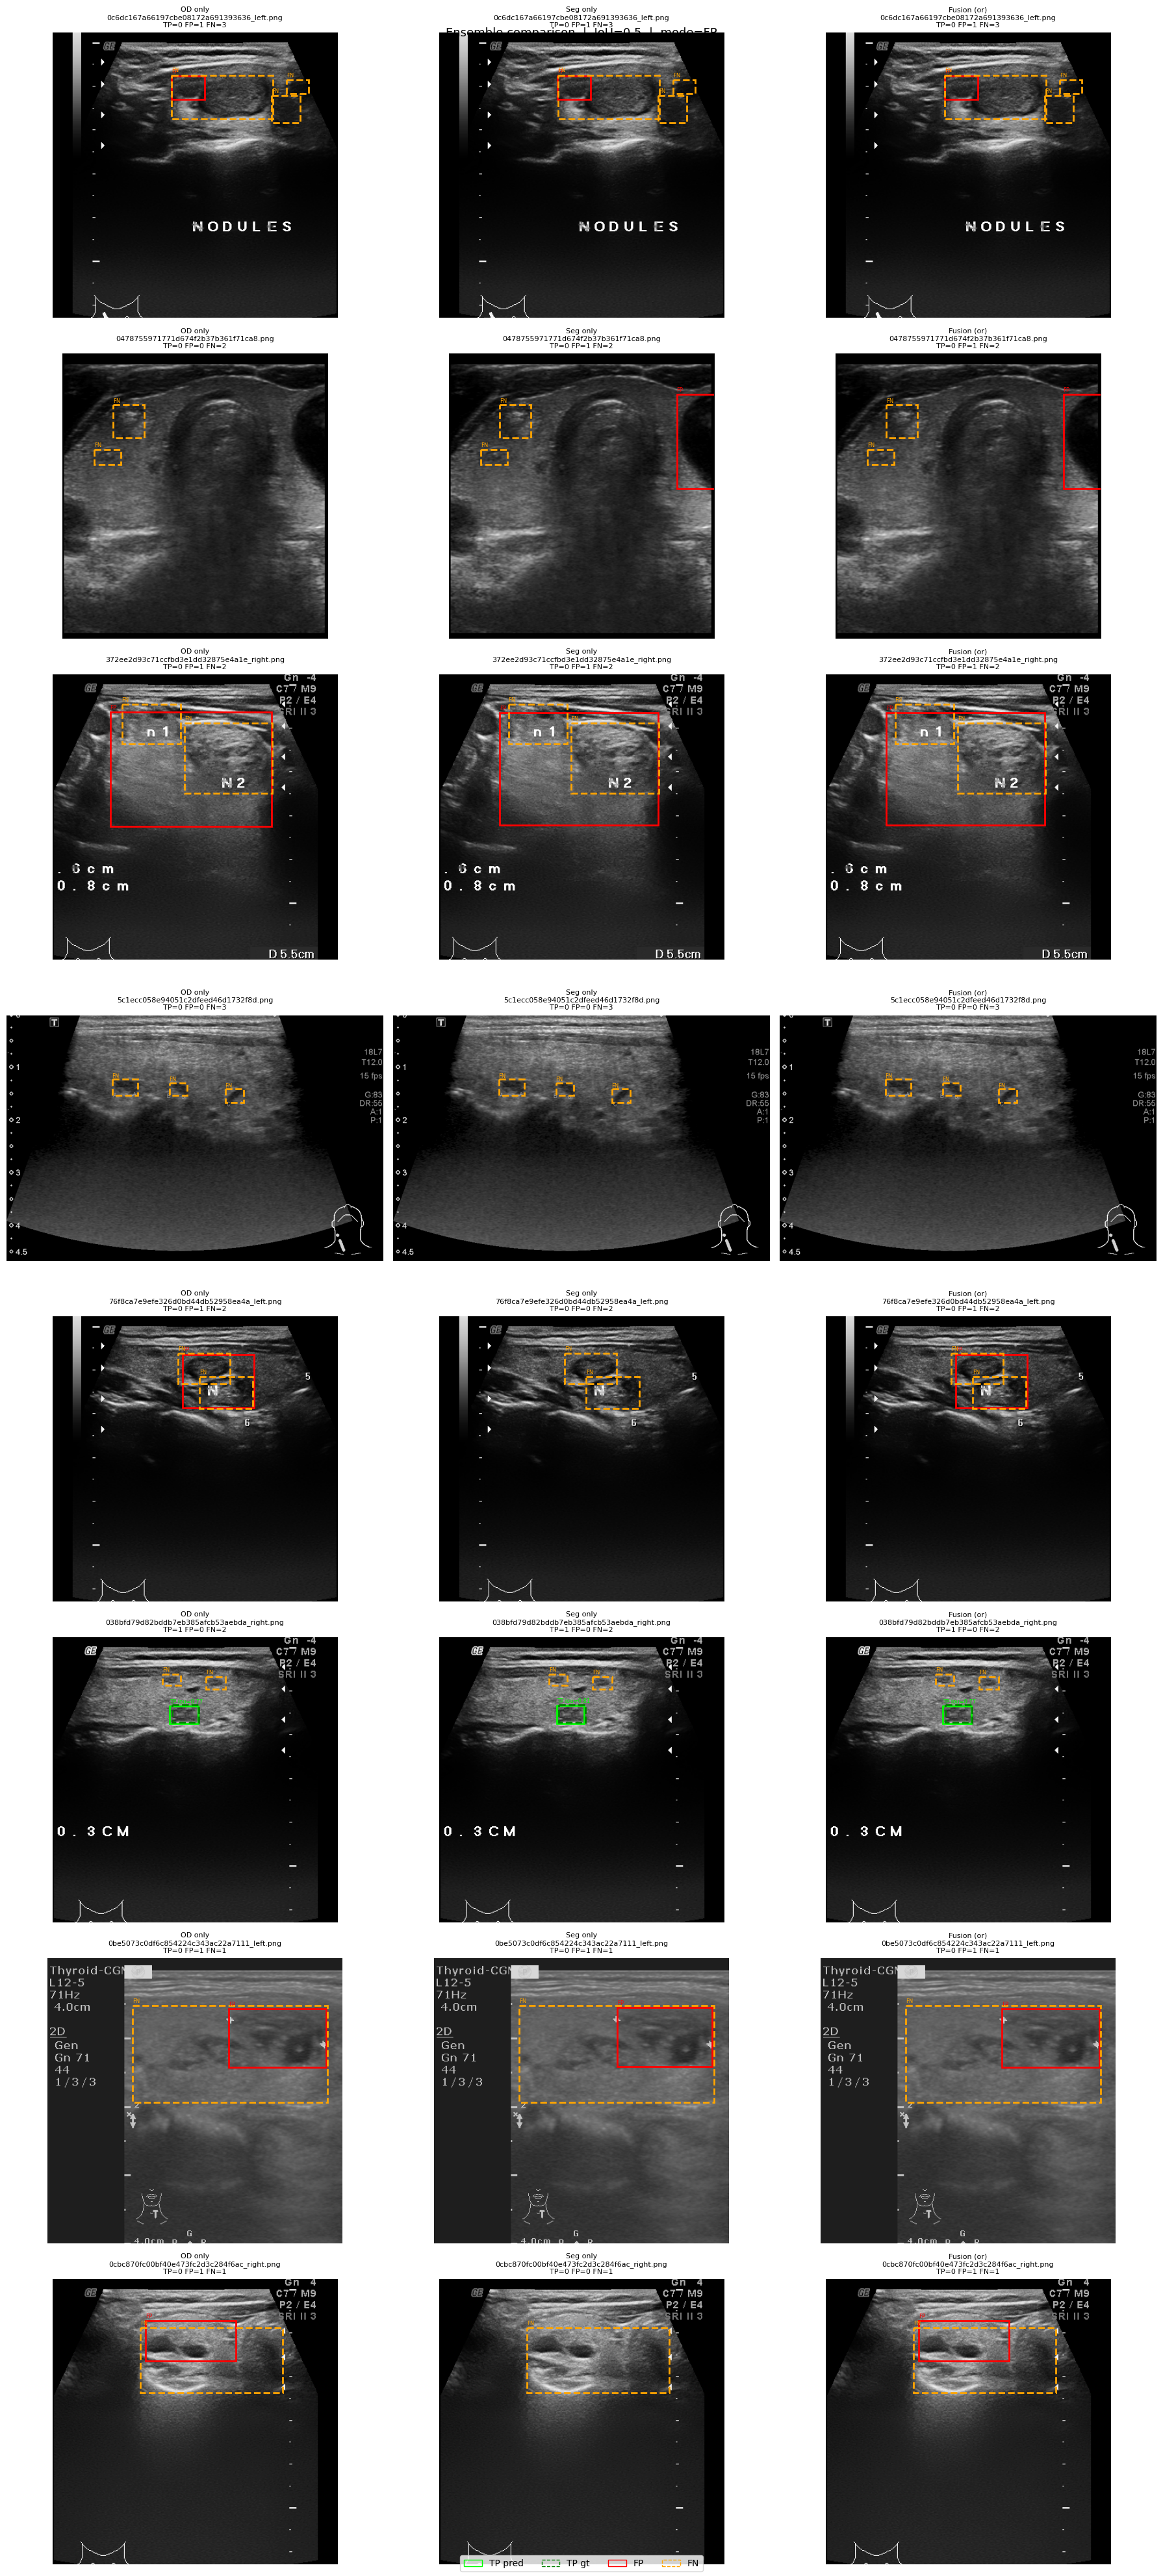

In [15]:
# 調整 mode: 'random' | 'fp' | 'fn' | 'worst'
# 調整 strategy: 'or' | 'and'

visualize_ensemble_samples(
    od_raw, seg_raw, results_by_strategy_iou,
    od_root=od_root,
    strategy='or',
    iou_threshold=0.5,
    n=8,
    mode='FP',
)